In [6]:
import scipy.io as sio
import numpy as np
from scipy.signal import butter, filtfilt
from mne.decoding import CSP
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt

In [7]:
def bandpass_filter(data, lowcut=8, highcut=30, fs=250, order=4):
    """Applies a Butterworth bandpass filter to EEG data."""
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

In [8]:
def load_BCI2a_data(data_path, subject, training, all_trials=True):    
    # Define MI-trials parameters
    n_channels = 22
    n_tests = 6 * 48     
    window_Length = 7 * 250  # Total trial duration (7s)

    # Define MI trial window 
    fs = 250          # Sampling rate
    t1 = int(2 * fs)  # Start time_point (2s)
    t2 = int(6 * fs)  # End time_point (6s)

    class_return = np.zeros(n_tests)
    data_return = np.zeros((n_tests, n_channels, window_Length))  #(trials x channels x time)

    NO_valid_trial = 0
    if training:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'T.mat')   #()
    else:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'E.mat')

    a_data = a['data']  #()
    
    for ii in range(a_data.size):
        a_data1 = a_data[0, ii]
        a_data2 = [a_data1[0, 0]]
        a_data3 = a_data2[0]
        a_X = a_data3[0]  # EEG signals
        a_trial = a_data3[1]  # Trial start indices
        a_y = a_data3[2]  # Class labels
        a_artifacts = a_data3[5]  # Artifact presence

        for trial in range(a_trial.size):
            if a_artifacts[trial] != 0 and not all_trials:
                continue
            # Extract EEG trial (time x channels) and transpose to (channels x time)
            trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
            
            # Apply bandpass filter
            trial_data = bandpass_filter(trial_data, lowcut=8, highcut=30, fs=fs, order=4)

            data_return[NO_valid_trial, :, :] = trial_data
            class_return[NO_valid_trial] = int(a_y[trial])
            NO_valid_trial += 1        

    # Keep only valid trials and select MI window (2s to 6s)
    data_return = data_return[0:NO_valid_trial, :, t1:t2]
    class_return = class_return[0:NO_valid_trial]
    class_return = (class_return - 1).astype(int)  # Convert to zero-based index

    return data_return, class_return

In [9]:
import torch
import numpy as np
from torch_geometric.data import Data, Dataset
from itertools import combinations

class EEGGraphDataset(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, spec_coh_values, transform=None):
        self.epochs = X                  # shape: [n_samples, 22 x T]
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform
        self.spec_coh_values = spec_coh_values  # shape: [n_samples, 231]

        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = list(range(len(self.ch_names)))  # [0..21]

        # Build undirected edge index for upper triangle (no self-loops)
        edge_list = list(combinations(self.node_ids, 2))  # 231 edges
        self.edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()

        real_idx = self.indices[idx]

        # Shape: [22, time_steps]
        node_features = torch.from_numpy(self.epochs[real_idx].reshape(22, -1)).float()

        # Get spectral coherence values for current sample: shape [231]
        edge_weights = torch.tensor(self.spec_coh_values[real_idx], dtype=torch.float32)

        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=real_idx,
            y=torch.tensor(self.labels[real_idx], dtype=torch.long)
        )

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, ChebConv, SAGEConv, global_mean_pool

# --- GNN Blocks with LayerNorm ---

class GraphConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = GraphConv(hidden_channels, hidden_channels)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = GraphConv(hidden_channels, hidden_channels // 2)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class ChebConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = ChebConv(hidden_channels, hidden_channels // 2, K)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class SAGEConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels // 2)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index)))
        x = F.relu(self.ln2(self.conv2(x, edge_index)))
        x = F.relu(self.ln3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

# --- Transformer Block (unchanged) ---

class TransformerBlock(nn.Module):
    def __init__(self, input_dim, nhead=4, num_layers=2, dim_feedforward=256):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        return self.transformer(x)

# --- Combined GNN + Transformer Model with LayerNorm ---

class GraphTransformerNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=3, transformer_heads=4, transformer_layers=3,dropouts=0.5):
        super().__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)

        self.feature_dim = (hidden_channels // 2) * 3
        assert self.feature_dim % transformer_heads == 0, "embed_dim must be divisible by num_heads"

        self.transformer = TransformerBlock(
            input_dim=self.feature_dim,
            nhead=transformer_heads,
            num_layers=transformer_layers
        )

        self.mlp = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_channels),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels // 2),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index, edge_weight, batch):
        g1 = self.graph_block(x, edge_index, edge_weight, batch)
        g2 = self.cheb_block(x, edge_index, edge_weight, batch)
        g3 = self.sage_block(x, edge_index, edge_weight, batch)

        x = torch.cat([g1, g2, g3], dim=1)

        x = x.unsqueeze(1)  # (batch_size, seq_len=1, feature_dim)
        x = self.transformer(x)
        x = x[:, 0, :]  # back to (batch_size, feature_dim)

        return self.mlp(x)

In [30]:
train_data, train_labels = load_BCI2a_data('/Users/siddharth/Documents/Brainconnectivity/BCI_Kaggle/', subject=0, training=True, all_trials=True)
test_data, test_labels = load_BCI2a_data('/Users/siddharth/Documents/Brainconnectivity/BCI_Kaggle/', subject=0, training=False, all_trials=True)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [31]:
train_mask = np.logical_or(train_labels == 0, train_labels == 1)
train_data_binary = train_data[train_mask]
train_labels_binary = train_labels[train_mask]

# Filter test data
test_mask = np.logical_or(test_labels == 0, test_labels == 1)
test_data_binary = test_data[test_mask]
test_labels_binary = test_labels[test_mask]

csp = CSP(n_components=22, reg=None, log=True, norm_trace=False,transform_into='average_power')
train_csp = csp.fit_transform(train_data_binary, train_labels_binary)

test_csp = csp.transform(test_data_binary)


In [36]:
print("Class distribution in binary train set:", np.bincount(train_labels_binary))
print("Class distribution in binary test set:", np.bincount(test_labels_binary))

Class distribution in binary train set: [72 72]
Class distribution in binary test set: [72 72]


In [11]:
import numpy as np
from scipy.signal import coherence
from tqdm import tqdm

def compute_spectral_coherence(data, sfreq=250):
    """
    Compute coherence between all pairs of channels for each sample.
    
    Args:
        data: np.ndarray, shape (samples, channels, time)
        sfreq: Sampling frequency
    
    Returns:
        np.ndarray, shape (samples, num_edges), coherence values averaged over frequencies
    """
    n_samples, n_channels, _ = data.shape
    coherence_features = []

    for sample in tqdm(data, desc="Computing coherence"):
        sample_coherence = []
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                f, coh = coherence(sample[i], sample[j], fs=sfreq, nperseg=256)
                avg_coh = np.mean(coh)  # Optionally, take band average
                sample_coherence.append(avg_coh)
        coherence_features.append(sample_coherence)

    return np.array(coherence_features)

In [18]:
def extract_channelwise_csp_train_test(train_data, train_labels, test_data):
    """
    Extract 1 CSP feature per channel for both train and test using CSP filters trained on train data only.
    
    Args:
        train_data: shape (n_trials, n_channels, n_times)
        train_labels: shape (n_trials,)
        test_data: shape (n_trials, n_channels, n_times)
    
    Returns:
        train_features: (n_trials_train, n_channels)
        test_features: (n_trials_test, n_channels)
    """
    n_trials_train, n_channels, _ = train_data.shape
    n_trials_test = test_data.shape[0]
    
    train_features = np.zeros((n_trials_train, n_channels))
    test_features  = np.zeros((n_trials_test, n_channels))
    
    csp_models = []
    
    for ch in range(n_channels):
        # Extract single-channel data for training and testing
        train_ch = train_data[:, ch:ch+1, :]
        test_ch  = test_data[:, ch:ch+1, :]
        
        # Fit CSP on training data for this channel
        csp = CSP(n_components=22, reg=None, log=True, norm_trace=False)
        train_csp = csp.fit_transform(train_ch, train_labels)  # shape: (n_trials_train, 1)
        test_csp  = csp.transform(test_ch)                    # shape: (n_trials_test, 1)
        
        # Save features
        train_features[:, ch] = train_csp[:, 0]
        test_features[:, ch]  = test_csp[:, 0]
        
        # Optional: store CSP model if needed later
        csp_models.append(csp)
    
    return train_features, test_features, csp_models

In [19]:
train_data, train_labels = load_BCI2a_data('BCI_Kaggle/', subject=0, training=True, all_trials=True)
test_data, test_labels = load_BCI2a_data('BCI_Kaggle/', subject=0, training=False, all_trials=True)

# 2. Binary Class Filter (Classes 0 and 1 only)
train_mask = np.isin(train_labels, [0, 1])
test_mask = np.isin(test_labels, [0, 1])

train_data_binary = train_data[train_mask]
train_labels_binary = train_labels[train_mask]

test_data_binary = test_data[test_mask]
test_labels_binary = test_labels[test_mask]

# 3. CSP Feature Extraction
train_features, test_features, csp_models = extract_channelwise_csp_train_test(
    train_data_binary, train_labels_binary, test_data_binary
)

# Optional reshape for (samples, channels, 1 feature) if needed downstream
train_features = train_features[:, :, np.newaxis]
test_features  = test_features[:, :, np.newaxis]

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 0.39 (2.2e-16 eps * 1 dim * 1.8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.37 (2.2e-16 eps * 1 dim * 1.7e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.4 (2.2e-16 eps * 1 dim * 1.8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1

In [20]:
# 6. Dataset Construction
train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
test_spec_coh  = compute_spectral_coherence(test_data_binary, sfreq=250)
train_dataset = EEGGraphDataset(
    X=train_features, 
    y=train_labels_binary, 
    indices=np.arange(len(train_labels_binary)), 
    loader_type="train", 
    sfreq=250,
    spec_coh_values=train_spec_coh
    
)

test_dataset = EEGGraphDataset(
    X=test_features, 
    y=test_labels_binary, 
    indices=np.arange(len(test_labels_binary)), 
    loader_type="test", 
    sfreq=250,
    spec_coh_values =test_spec_coh
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 2. Instantiate Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Computing coherence: 100%|██████████| 144/144 [00:10<00:00, 13.32it/s]


In [23]:
model = GraphTransformerNet(in_channels=1, hidden_channels=32, out_channels=1, K=3, transformer_heads=8,dropouts=0.3)


Epochs:  10%|█         | 100/1000 [00:55<08:19,  1.80it/s, Train Loss=0.6932, Train Acc=0.5000, Test Acc=0.4931, Test Kappa=-0.0139, Best Test Kappa=0.0000 (Epoch 1), Best Test Acc=0.5000 (Epoch 1)]


⏹️ Early stopping at epoch 101. No improvement for 100 consecutive epochs.


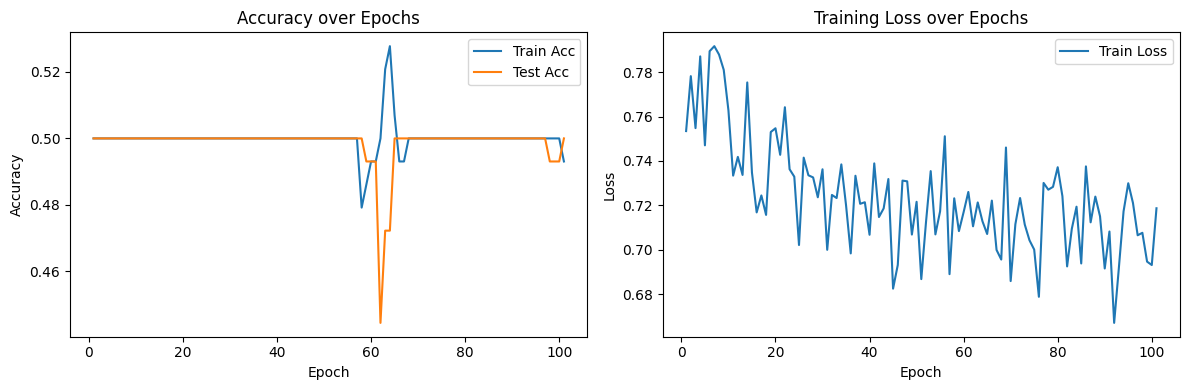

In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

# 4. Train Function
def train_model(model, train_loader):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
        loss = criterion(out, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)
from sklearn.metrics import cohen_kappa_score
def evaluate_model(model, data_loader, return_preds=False):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().float().numpy())
    acc = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    if return_preds:
        return acc, kappa, all_labels, all_preds
    return acc, kappa

# 6. Training Loop with Progress Bar and Metrics Logging
# 6. Training Loop with Early Stopping and Progress Bar
num_epochs = 1000
patience = 100
early_stop_counter = 0

best_test_acc = 0.0
best_epoch = 0
best_model_state = None
best_test_kappa = 0.0
train_losses = []
train_accuracies = []
test_accuracies = []

epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

for epoch in epoch_bar:
    train_loss = train_model(model, train_loader)
    train_acc, train_kappa = evaluate_model(model, train_loader)
    test_acc, test_kappa = evaluate_model(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    if test_kappa>best_test_kappa:
        best_test_kappa = test_kappa
        best_epoch = epoch
        best_model_state = model.state_dict()
    # Check for improvement
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        best_model_state = model.state_dict()  # Save best model
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    # Early stopping condition
    if early_stop_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
        break

    epoch_bar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Train Acc': f'{train_acc:.4f}',
        'Test Acc': f'{test_acc:.4f}',
        'Test Kappa': f'{test_kappa:.4f}',
        'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
        'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
    })
# Load the best model state before evaluation
if best_model_state:
    model.load_state_dict(best_model_state)

# final_acc, final_kappa = evaluate_model(model, test_loader)
# print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
# print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


# 7. Optional: Plot Learning Curves
def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, test_accuracies, label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_learning_curves(train_losses, train_accuracies, test_accuracies)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 36 (2.2e-16 eps * 22 dim * 7.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  11%|█▏        | 114/1000 [01:04<08:21,  1.77it/s, Train Loss=0.3548, Train Acc=0.9306, Test Acc=0.8194, Test Kappa=0.6389, Best Test Kappa=0.7778 (Epoch 15), Best Test Acc=0.8889 (Epoch 15)]


⏹️ Early stopping at epoch 115. No improvement for 100 consecutive epochs.


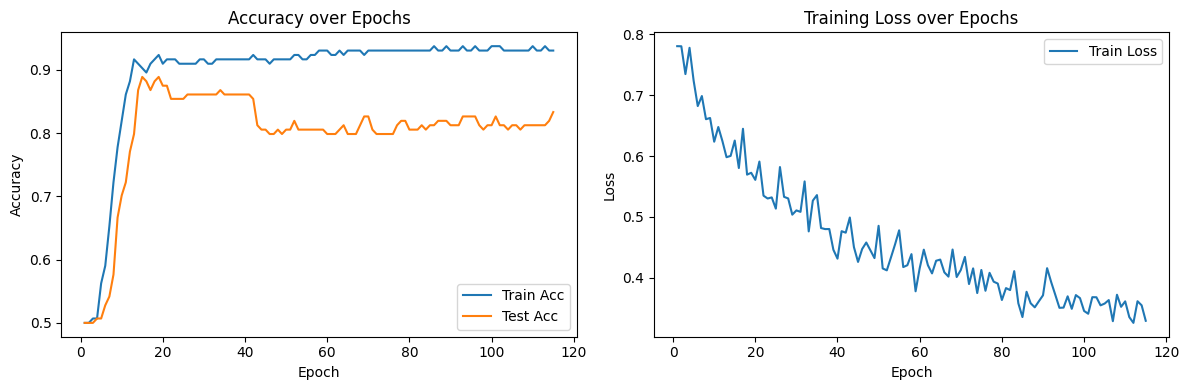

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 41 (2.2e-16 eps * 22 dim * 8.4e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  14%|█▍        | 143/1000 [01:35<09:33,  1.50it/s, Train Loss=0.5859, Train Acc=0.8264, Test Acc=0.5486, Test Kappa=0.0972, Best Test Kappa=0.1528 (Epoch 44), Best Test Acc=0.5764 (Epoch 44)]


⏹️ Early stopping at epoch 144. No improvement for 100 consecutive epochs.


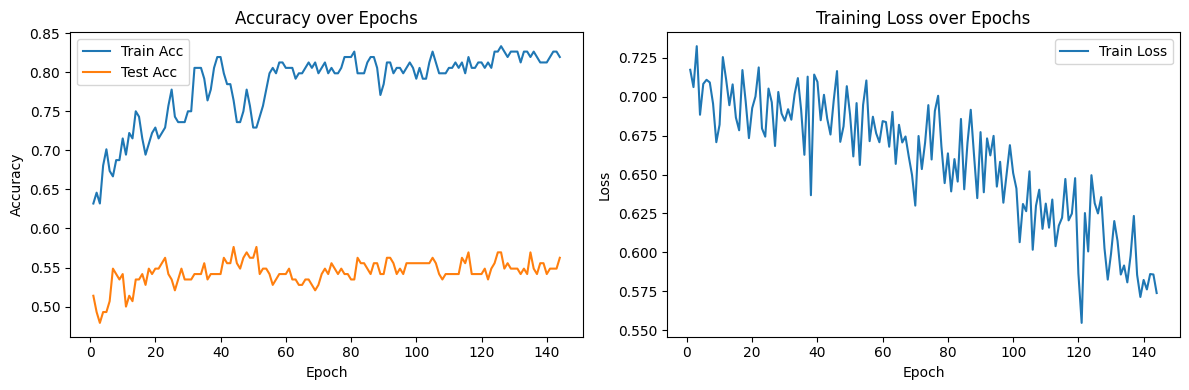

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  30%|███       | 301/1000 [03:07<07:14,  1.61it/s, Train Loss=0.1421, Train Acc=1.0000, Test Acc=0.9167, Test Kappa=0.8333, Best Test Kappa=0.8611 (Epoch 202), Best Test Acc=0.9306 (Epoch 202)]


⏹️ Early stopping at epoch 302. No improvement for 100 consecutive epochs.


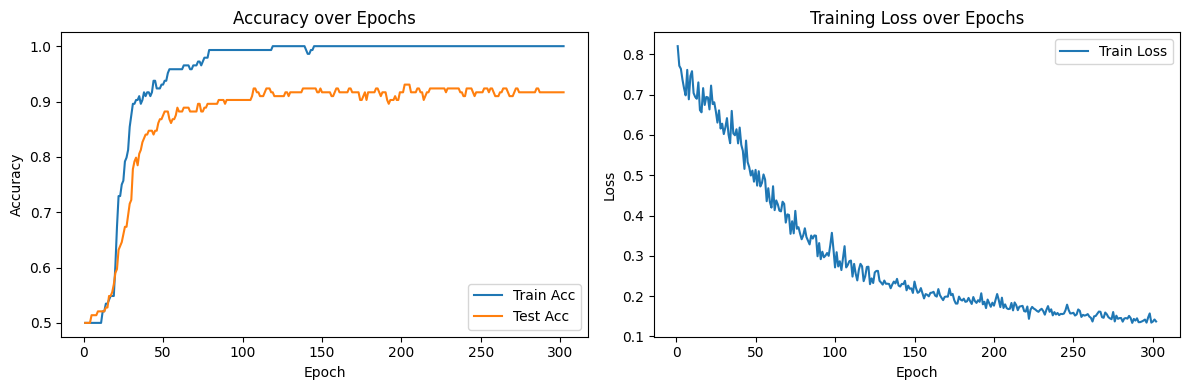

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 34 (2.2e-16 eps * 22 dim * 6.9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  24%|██▎       | 235/1000 [02:55<09:30,  1.34it/s, Train Loss=0.2439, Train Acc=0.9653, Test Acc=0.7292, Test Kappa=0.4583, Best Test Kappa=0.5000 (Epoch 136), Best Test Acc=0.7500 (Epoch 136)]


⏹️ Early stopping at epoch 236. No improvement for 100 consecutive epochs.


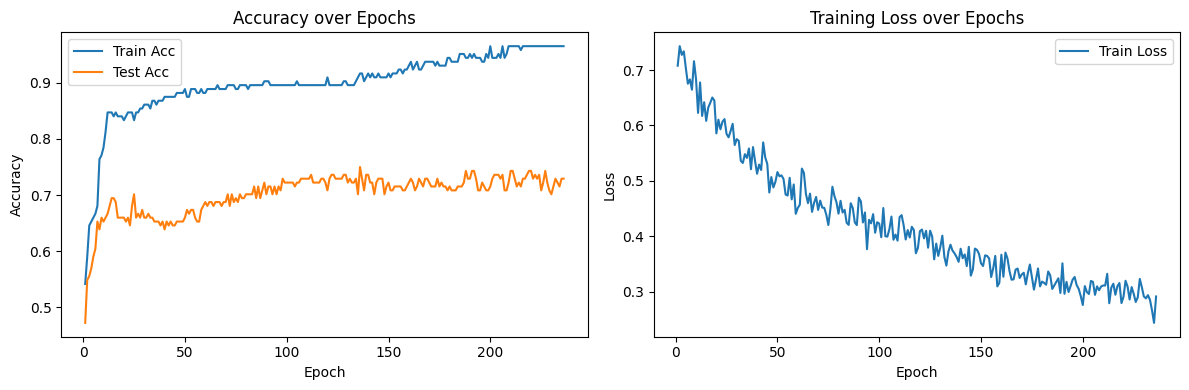

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_28305/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 30 (2.2e-16 eps * 22 dim * 6.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Epochs:  10%|█         | 105/1000 [00:49<06:58,  2.14it/s, Train Loss=0.6539, Train Acc=0.7431, Test Acc=0.5000, Test Kappa=0.0000, Best Test Kappa=0.0556 (Epoch 33), Best Test Acc=0.5278 (Epoch 33)] 


KeyboardInterrupt: 

In [93]:
for subi in range(0,9):
    train_data, train_labels = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
    test_data, test_labels = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)

    # 2. Binary Class Filter (Classes 0 and 1 only)
    train_mask = np.isin(train_labels, [0, 1])
    test_mask = np.isin(test_labels, [0, 1])

    train_data_binary = train_data[train_mask]
    train_labels_binary = train_labels[train_mask]

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask]

    # 3. CSP Feature Extraction
    csp = CSP(n_components=22, reg=None, log=True, norm_trace=False, transform_into='average_power')

    train_csp = csp.fit_transform(train_data_binary, train_labels_binary)
    test_csp = csp.transform(test_data_binary)

    # 4. Repeat CSP features across channels (to match shape expected by Graph Transformer)
    #    Assumes input to EEGGraphDataset expects shape: (samples, channels, features)
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (N, 22, 22)
    test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)

    # 5. Compute Spectral Coherence (likely used inside EEGGraphDataset)
    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh  = compute_spectral_coherence(test_data_binary, sfreq=250)

    # 6. Dataset Construction
# 6. Dataset Construction
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_labels_binary, 
        indices=np.arange(len(train_labels_binary)), 
        loader_type="train", 
        sfreq=250,
        spec_coh_values=train_spec_coh
        
    )

    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_labels_binary, 
        indices=np.arange(len(test_labels_binary)), 
        loader_type="test", 
        sfreq=250,
        spec_coh_values =test_spec_coh
    )

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # 2. Instantiate Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=22, hidden_channels=32, out_channels=1, K=3, transformer_heads=8,dropouts=0.3)


    # 3. Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    # 4. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    from sklearn.metrics import cohen_kappa_score
    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # 6. Training Loop with Progress Bar and Metrics Logging
    # 6. Training Loop with Early Stopping and Progress Bar
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_test_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_test_kappa = 0.0
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        test_acc, test_kappa = evaluate_model(model, test_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        if test_kappa>best_test_kappa:
            best_test_kappa = test_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        # Check for improvement
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_model_state = model.state_dict()  # Save best model
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # Early stopping condition
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test Kappa': f'{test_kappa:.4f}',
            'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
            'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
        })
    # Load the best model state before evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    # final_acc, final_kappa = evaluate_model(model, test_loader)
    # print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    # print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


    # 7. Optional: Plot Learning Curves
    def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(12, 4))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, test_accuracies, label='Test Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Call the plotting function
    plot_learning_curves(train_losses, train_accuracies, test_accuracies)


=== Subject 0 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 8.9e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.7e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9.1e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covar

Epochs:  14%|█▍        | 143/1000 [11:43<1:10:14,  4.92s/it, Train Loss=0.7069, Train Acc=0.5366, Val Acc=0.4989, Val Kappa=-0.0068, Best Val Kappa=0.0311 (Epoch 44), Best Val Acc=0.5184 (Epoch 44)]


⏹️ Early stopping at epoch 144. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5000
📊 Final Test Cohen’s Kappa Score: 0.0000


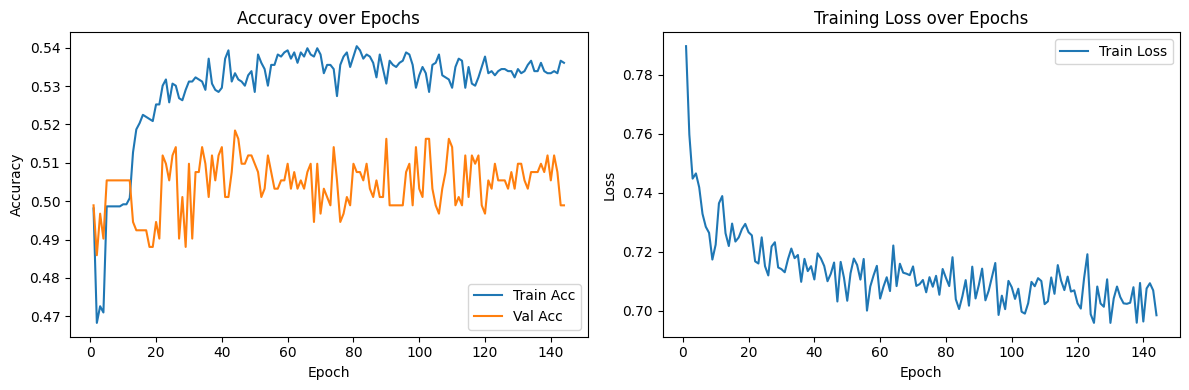


=== Subject 1 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.6e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.4e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 8.8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 cov

Epochs:  12%|█▏        | 121/1000 [08:23<1:00:57,  4.16s/it, Train Loss=0.6901, Train Acc=0.5524, Val Acc=0.5423, Val Kappa=0.0802, Best Val Kappa=0.1607 (Epoch 22), Best Val Acc=0.5770 (Epoch 22)]


⏹️ Early stopping at epoch 122. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5104
📊 Final Test Cohen’s Kappa Score: 0.0208


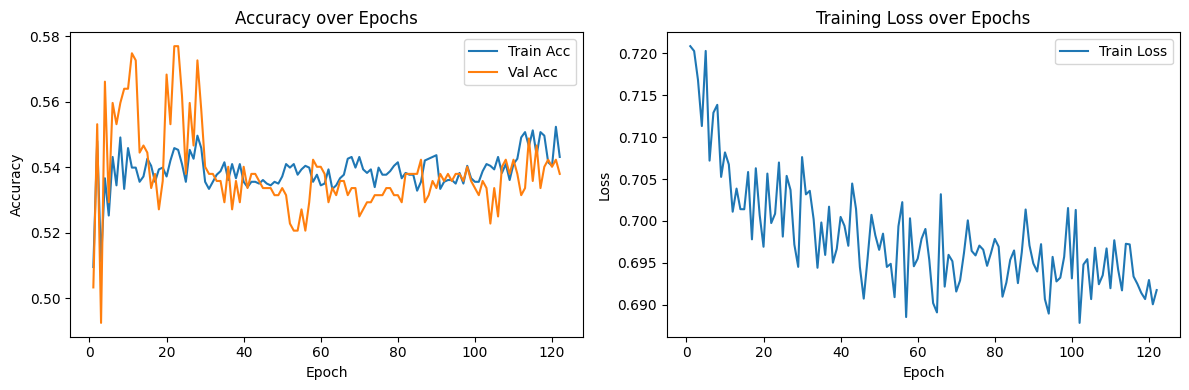


=== Subject 2 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 8.8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.4e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 8.9e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covar

Epochs:  13%|█▎        | 131/1000 [09:00<59:43,  4.12s/it, Train Loss=0.6903, Train Acc=0.5290, Val Acc=0.5206, Val Kappa=0.0182, Best Val Kappa=0.1086 (Epoch 39), Best Val Acc=0.5748 (Epoch 39)]  


⏹️ Early stopping at epoch 132. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5660
📊 Final Test Cohen’s Kappa Score: 0.1319


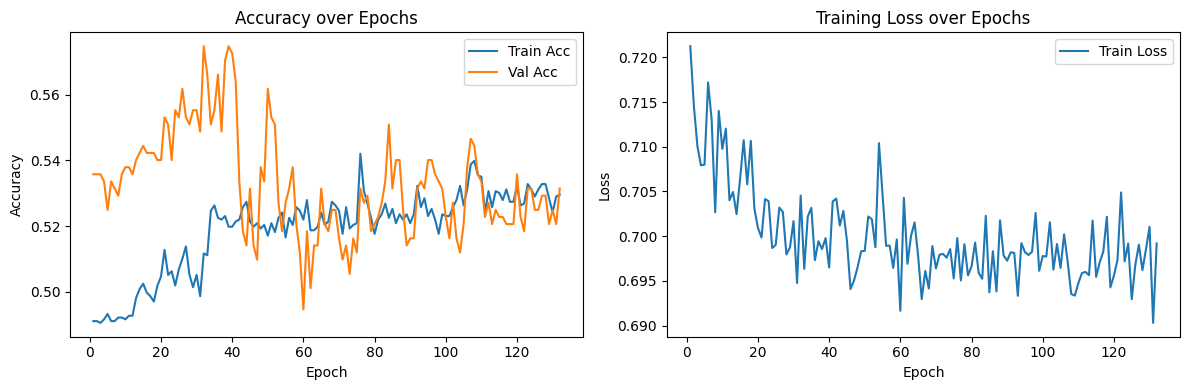


=== Subject 3 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.7e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9.1e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covaria

Epochs:  17%|█▋        | 167/1000 [11:22<56:46,  4.09s/it, Train Loss=0.6955, Train Acc=0.5317, Val Acc=0.5466, Val Kappa=0.0986, Best Val Kappa=0.1146 (Epoch 161), Best Val Acc=0.5553 (Epoch 161)]


⏹️ Early stopping at epoch 168. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5000
📊 Final Test Cohen’s Kappa Score: 0.0000


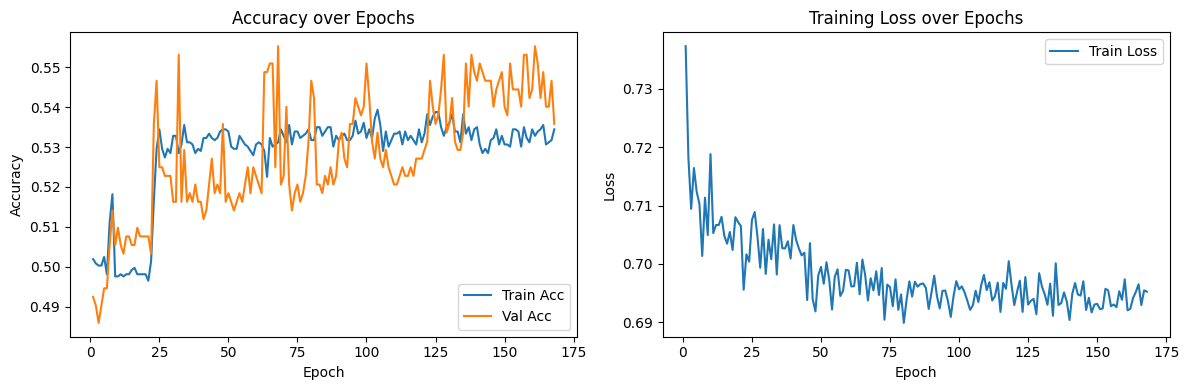


=== Subject 4 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9.2e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covaria

Epochs:  23%|██▎       | 227/1000 [15:07<51:30,  4.00s/it, Train Loss=0.6819, Train Acc=0.5974, Val Acc=0.5553, Val Kappa=0.1105, Best Val Kappa=0.1320 (Epoch 128), Best Val Acc=0.5662 (Epoch 128)]


⏹️ Early stopping at epoch 228. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4965
📊 Final Test Cohen’s Kappa Score: -0.0069


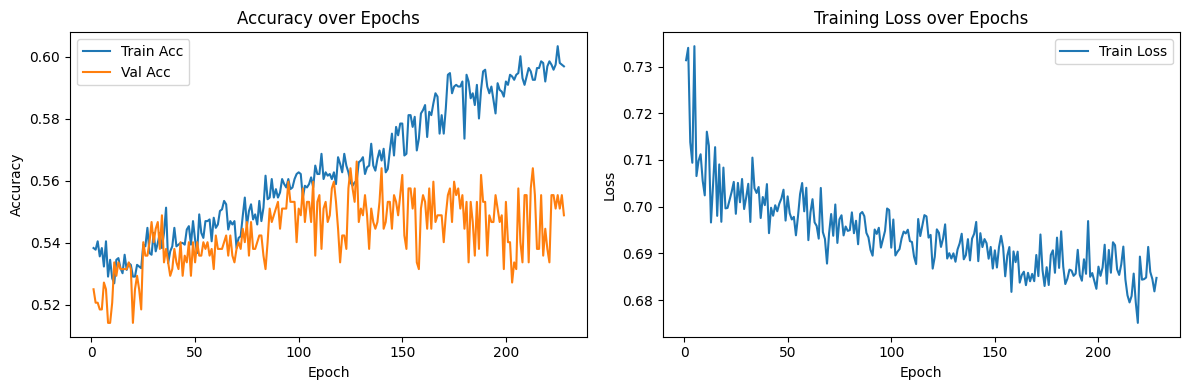


=== Subject 5 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.7e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.4e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 8.9e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 cov

Epochs:  42%|████▏     | 422/1000 [11:22:51<15:35:17, 97.09s/it, Train Loss=0.6830, Train Acc=0.5855, Val Acc=0.5835, Val Kappa=0.1833, Best Val Kappa=0.2189 (Epoch 323), Best Val Acc=0.6095 (Epoch 323)]     


⏹️ Early stopping at epoch 423. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4688
📊 Final Test Cohen’s Kappa Score: -0.0625


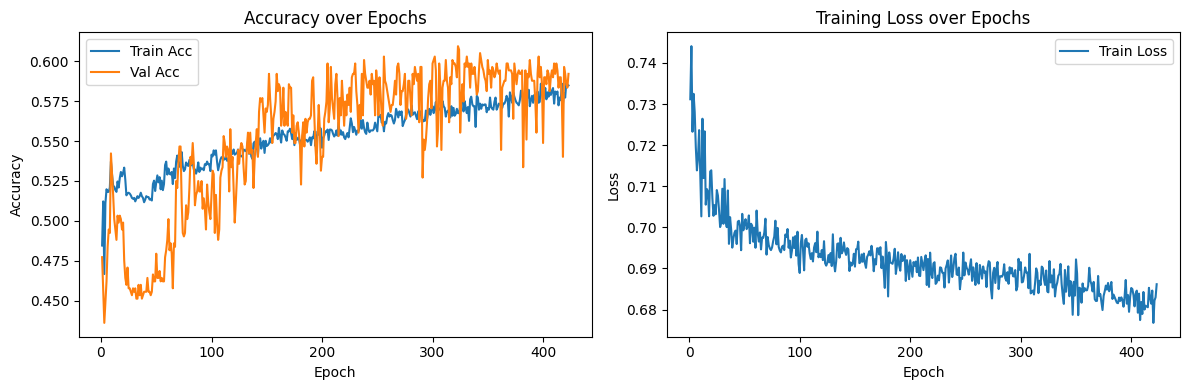


=== Subject 6 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.7e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 1 dim * 9.1e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covaria

Epochs:  10%|█         | 101/1000 [04:35<40:52,  2.73s/it, Train Loss=0.7019, Train Acc=0.5393, Val Acc=0.4967, Val Kappa=0.0092, Best Val Kappa=0.0463 (Epoch 95), Best Val Acc=0.5228 (Epoch 95)]


⏹️ Early stopping at epoch 102. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5000
📊 Final Test Cohen’s Kappa Score: 0.0000


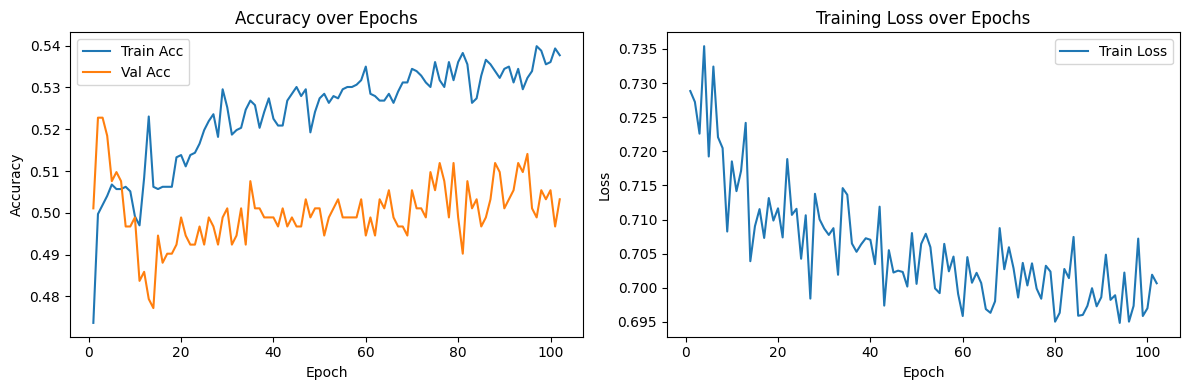


=== Subject 7 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.8 (2.2e-16 eps * 1 dim * 8.2e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.8 (2.2e-16 eps * 1 dim * 8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.4e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 cov

Epochs:  27%|██▋       | 269/1000 [14:45<40:07,  3.29s/it, Train Loss=0.6930, Train Acc=0.5458, Val Acc=0.5640, Val Kappa=0.1297, Best Val Kappa=0.1546 (Epoch 170), Best Val Acc=0.5792 (Epoch 170)]


⏹️ Early stopping at epoch 270. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5000
📊 Final Test Cohen’s Kappa Score: 0.0000


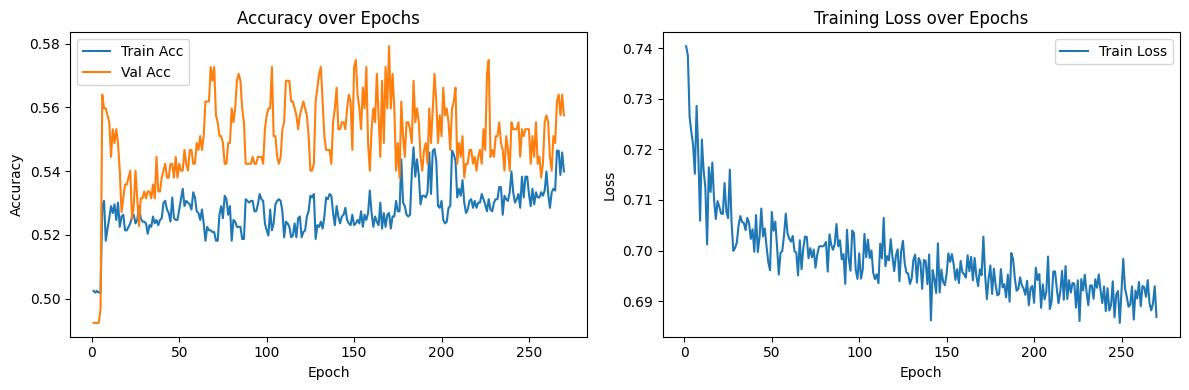


=== Subject 8 held out for testing ===


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_57354/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.6e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.8 (2.2e-16 eps * 1 dim * 8.3e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.9 (2.2e-16 eps * 1 dim * 8.7e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 c

Epochs:  10%|█         | 100/1000 [09:53<1:29:04,  5.94s/it, Train Loss=0.6898, Train Acc=0.5686, Val Acc=0.4924, Val Kappa=-0.0161, Best Val Kappa=0.0123 (Epoch 12), Best Val Acc=0.5098 (Epoch 12)]


⏹️ Early stopping at epoch 101. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4826
📊 Final Test Cohen’s Kappa Score: -0.0347


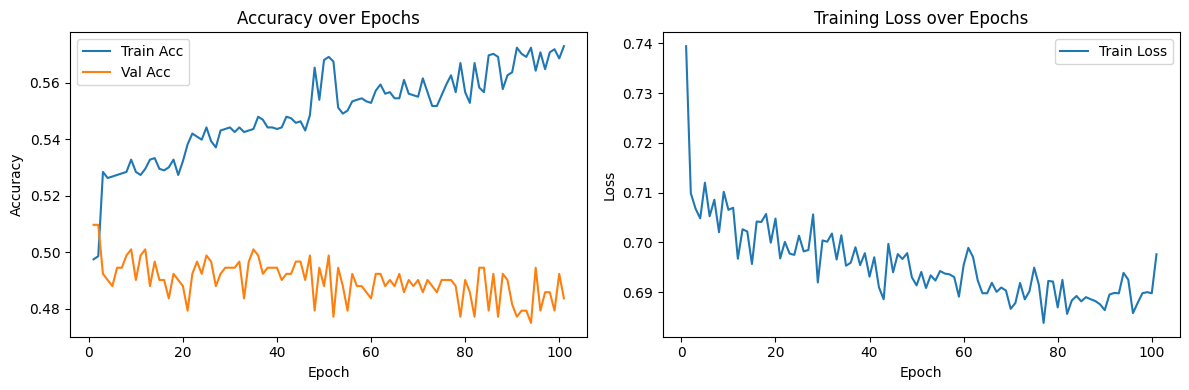

In [26]:
for test_sub in range(0, 9):
    print(f"\n=== Subject {test_sub} held out for testing ===")
    train_data_all = []
    train_labels_all = []
    test_data = []
    test_labels = []

    for subi in range(0, 9):
        if subi != test_sub:
            train_data_1, train_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
            train_data_2, train_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
            train_data_all.append(train_data_1)
            train_labels_all.append(train_labels_1)
            train_data_all.append(train_data_2)
            train_labels_all.append(train_labels_2)

    train_data_all = np.concatenate(train_data_all, axis=0)
    train_labels_all = np.concatenate(train_labels_all, axis=0)

    test_data_1, test_labels_1 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=True, all_trials=True)
    test_data_2, test_labels_2 = load_BCI2a_data('BCI_Kaggle/', subject=test_sub, training=False, all_trials=True)

    test_data.append(test_data_1)
    test_labels.append(test_labels_1)
    test_data.append(test_data_2)
    test_labels.append(test_labels_2)

    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # Binary Class Filter (Classes 1 and 2, shifted to 0 and 1)
    train_mask = np.isin(train_labels_all, [1, 2])
    test_mask = np.isin(test_labels, [1, 2])

    train_data_binary = train_data_all[train_mask]
    train_labels_binary = train_labels_all[train_mask] - 1

    test_data_binary = test_data[test_mask]
    test_labels_binary = test_labels[test_mask] - 1

    # CSP Feature Extraction
    train_features, test_features, csp_models = extract_channelwise_csp_train_test(
        train_data_binary, train_labels_binary, test_data_binary
    )

    # Optional reshape for (samples, channels, 1 feature) if needed downstream
    train_features = train_features[:, :, np.newaxis]
    test_features  = test_features[:, :, np.newaxis]

    train_spec_coh = compute_spectral_coherence(train_data_binary, sfreq=250)
    test_spec_coh = compute_spectral_coherence(test_data_binary, sfreq=250)

    train_dataset = EEGGraphDataset(
        X=train_features,
        y=train_labels_binary,
        indices=np.arange(len(train_labels_binary)),
        loader_type="train",
        sfreq=250,
        spec_coh_values=train_spec_coh
    )

    test_dataset = EEGGraphDataset(
        X=test_features,
        y=test_labels_binary,
        indices=np.arange(len(test_labels_binary)),
        loader_type="test",
        sfreq=250,
        spec_coh_values=test_spec_coh
    )

    # Split training dataset into 80% training and 20% validation
    from torch.utils.data import random_split

    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=1, hidden_channels=32, out_channels=1, K=3, transformer_heads=8, dropouts=0.3).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    from sklearn.metrics import accuracy_score, cohen_kappa_score

    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
                probs = torch.sigmoid(out)
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().float().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # Training Loop with Early Stopping
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    from tqdm import trange
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        val_acc, val_kappa = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })

    # Load best model and evaluate on test set
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")

    # Plot learning curves
    def plot_learning_curves(train_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, val_accuracies, label='Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    plot_learning_curves(train_losses, train_accuracies, val_accuracies)
